# Clarke & Wright savings heuristic for the CVRP — sequential and parallel versions

**Capacitated Vehicle Routing Problem (CVRP).** A fleet of identical vehicles of capacity
$Q$ leaves a single depot (node 0). Every customer $i$ has a demand $q_i$ and must be
visited exactly once, each route starts and ends at the depot, the load of a route cannot
exceed $Q$, and the goal is to minimise the total distance travelled.

**Clarke & Wright savings (CWS).** Start from a trivially feasible but expensive solution
in which every customer has its own vehicle, $0 \to i \to 0$. Serving $i$ and $j$ on the
same route instead of on two separate ones saves

$$
s(i, j) = c(0, i) + c(0, j) - c(i, j),
$$

because the two trips $i \to 0$ and $0 \to j$ are replaced by the single edge $i \to j$.
The heuristic sorts all customer pairs by decreasing saving and merges routes along those
edges whenever the merge is feasible.

There are two classic ways of walking the savings list:

* **Parallel** — any two routes can be merged at any time, so many routes grow at once.
  This is the version used by Juan et al. (2011).
* **Sequential** — a single route is grown until no feasible merge is left for it; then it
  is closed and the next route is started.

This notebook implements and explains both versions, first the **sequential** one and then
the **parallel** one. All the building blocks
live in [`vrp.py`](vrp.py); here each of them is called in turn on a small instance, and the
complete heuristic is then run on the 33 benchmark instances and compared with the CWS costs
reported by Juan et al. (2011).

The scope is the one set by the assignment, the classic CWS, not the full algorithm of the
paper (SR-GCWS-CS). In terms of its Figure 4 only lines 1–2 are covered — build the savings
list and construct the CWS solution. The construction loop has the structure of its Figure 5
but always takes the first edge of the list instead of a random one; the randomised
multi-start, the routes cache and the splitting are left out.

> Juan, A. A., Faulín, J., Jorba, J., Riera, D., Masip, D. & Barrios, B. (2011). On the use
> of Monte Carlo simulation, cache and splitting techniques to improve the Clarke and Wright
> savings heuristics. *Journal of the Operational Research Society* 62(6), 1085–1097.

In [1]:
import time
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import vrp

RESULTS_DIR = Path("../results")
FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Categorical colours, one per route, always assigned in this order.
ROUTE_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
                "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, MUTED = "#0b0b0b", "#8a8984"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "font.size": 9})

In [2]:
def plot_routes(coords, routes, ax, title=""):
    '''Draw the depot, the customers and every route as a closed tour, labelled by number.'''
    for k, route in enumerate(routes):
        color = ROUTE_COLORS[k % len(ROUTE_COLORS)]
        tour = coords[[0, *route, 0]]
        ax.plot(tour[:, 0], tour[:, 1], color=color, lw=1.5, zorder=1)
        cx, cy = coords[route].mean(axis=0)
        ax.annotate(str(k + 1), (cx, cy), color=INK, fontsize=8, fontweight="bold",
                    ha="center", va="center",
                    bbox=dict(boxstyle="circle,pad=0.2", fc="white", ec=color, lw=1))
    ax.scatter(coords[1:, 0], coords[1:, 1], s=14, color=INK, zorder=2)
    ax.scatter(*coords[0], s=70, marker="s", color=INK, zorder=3)
    ax.set_title(title, loc="left", color=INK)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])

## 1. Loading an instance

`vrp.load_instance(name)` reads `../data/<name>_input_nodes.txt`. Every row is a node,
`x  y  demand`; the first row is the depot, whose coordinates have been translated to the
origin (distances are Euclidean, so the translation changes nothing). The vehicle capacity
is not in the file: it comes from the dictionary `vrp.CAPACITY`, copied from Table 1 of
Juan et al. (2011).

We use **A-n32-k5** as the running example: 1 depot + 31 customers, and the best-known
solution uses 5 vehicles.

In [3]:
name = "A-n32-k5"
coords, demand, capacity = vrp.load_instance(name)
n = len(demand)

print(f"{name}: {n} nodes (depot + {n - 1} customers), capacity Q = {capacity:g}")
print(f"total demand = {demand.sum():g}  ->  at least ceil({demand.sum():g}/{capacity:g}) "
      f"= {ceil(demand.sum() / capacity)} vehicles are needed")
pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "demand": demand}).head(6)

A-n32-k5: 32 nodes (depot + 31 customers), capacity Q = 100
total demand = 410  ->  at least ceil(410/100) = 5 vehicles are needed


,x,y,demand
0,0.0,0.0,0.0
1,14.0,-32.0,19.0
2,-32.0,-71.0,21.0
3,-33.0,-68.0,6.0
4,-69.0,-69.0,19.0
5,-53.0,13.0,7.0


## 2. Distance matrix

`vrp.distance_matrix(coords)` returns the $n \times n$ matrix of Euclidean distances
$c(i, j)$, **without rounding** (Juan et al. also report real, not integer, costs). It is
symmetric and has zeros on the diagonal.

In [4]:
dist = vrp.distance_matrix(coords)
print("shape:", dist.shape, "| symmetric:", np.allclose(dist, dist.T))
print("distance from the depot to customers 1..5:", dist[0, 1:6].round(2))

shape: (32, 32) | symmetric: True
distance from the depot to customers 1..5: [34.93 77.88 75.58 97.58 54.57]


## 3. Savings list

`vrp.make_savings_list(dist)` builds one candidate edge for every pair of customers
$i < j$ (the depot is excluded), computes its saving $s(i, j) = c(0,i) + c(0,j) - c(i,j)$
and sorts the edges from the largest to the smallest saving. Ties keep the order in which
the pairs were generated, as in the reference code of the course.

With $n - 1 = 31$ customers there are $31 \cdot 30 / 2 = 465$ edges. By the triangle
inequality every saving is non-negative. The largest savings come from pairs of customers
that are **close to each other and far from the depot**.

In [5]:
i_list, j_list, s_list = vrp.make_savings_list(dist)
print(f"{len(s_list)} edges in the savings list")
pd.DataFrame({"i": i_list, "j": j_list, "c(0,i)": dist[0, i_list], "c(0,j)": dist[0, j_list],
              "c(i,j)": dist[i_list, j_list], "saving": s_list}).head(10).round(2)

465 edges in the savings list


,i,j,"c(0,i)","c(0,j)","c(i,j)",saving
0,4,11,97.58,101.41,8.54,190.45
1,8,11,85.60,101.41,16.64,170.38
2,4,28,97.58,84.86,12.81,169.64
3,9,22,88.14,84.17,4.24,168.07
4,11,28,101.41,84.86,18.68,167.60
5,4,8,97.58,85.60,17.03,166.16
6,9,11,88.14,101.41,29.15,160.40
7,8,28,85.60,84.86,12.73,157.74
8,8,9,85.60,88.14,19.21,154.54
9,11,22,101.41,84.17,32.00,153.59


## 4. Initial (dummy) solution

`vrp.construct_initial_sol(demand)` creates the starting point of the heuristic: one route
$0 \to i \to 0$ per customer. It returns three structures that the rest of the algorithm
keeps up to date:

* `routes` — dictionary *route index → list of customers* (the depot at both ends is
  implicit). Initially route $i$ is just `[i]`.
* `route_of` — array with the route index of every node, so that the route of a customer
  is found in $O(1)$.
* `load` — total demand carried by each route.

Its cost is $2 \sum_i c(0, i)$: every customer costs a return trip to the depot.

In [6]:
routes, route_of, load = vrp.construct_initial_sol(demand)
initial = list(routes.values())
print(f"{len(initial)} routes, cost = {vrp.solution_cost(initial, dist):.2f} "
      f"(2 * sum c(0,i) = {2 * dist[0, 1:].sum():.2f})")

31 routes, cost = 3740.76 (2 * sum c(0,i) = 3740.76)


## 5. Merging conditions and the merge itself

Taking an edge $(i, j)$ from the savings list, the two routes containing $i$ and $j$ can be
merged through that edge only if `vrp.check_merging_conditions` holds:

1. **Different routes** — $i$ and $j$ are not already on the same route (the merge would
   close a cycle that never visits the depot).
2. **Both nodes are exterior** — $i$ and $j$ are adjacent to the depot, i.e. at one end of
   their routes (`vrp.is_exterior`). An interior node already has two neighbours, and
   linking it to a third one would not give a route.
3. **Capacity** — the load of the two routes together does not exceed $Q$.

If the conditions hold, `vrp.merge_routes_using_edge` reverses the routes if needed so that
the first one **ends** at $i$ and the second one **starts** at $j$, concatenates them,
re-labels the nodes of the second route and adds up the loads. The edges $(i, 0)$ and
$(0, j)$ disappear and $(i, j)$ appears, so the total cost drops by exactly $s(i, j)$.

Below, the first edge of the list is applied to the dummy solution.

In [7]:
i, j, s = i_list[0], j_list[0], s_list[0]
print(f"edge ({i}, {j}), saving {s:.2f}")
print("conditions hold:", vrp.check_merging_conditions(i, j, routes, route_of, load, capacity))

cost_before = vrp.solution_cost(list(routes.values()), dist)
r = vrp.merge_routes_using_edge(i, j, routes, route_of, load)
cost_after = vrp.solution_cost(list(routes.values()), dist)

print(f"merged route {r}: {routes[r]}, load {load[r]:g}")
print(f"cost {cost_before:.2f} -> {cost_after:.2f}, reduction {cost_before - cost_after:.2f} = saving")
print("same edge again (now same route):",
      vrp.check_merging_conditions(i, j, routes, route_of, load, capacity))

edge (4, 11), saving 190.45
conditions hold: True
merged route 4: [4, 11], load 33
cost 3740.76 -> 3550.31, reduction 190.45 = saving
same edge again (now same route): False


## 6. Sequential CWS

`vrp.sequential_cws(dist, demand, capacity)` puts the pieces together. Its loop has the
structure of Figure 5 in Juan et al. — take an edge, look up the routes of its two nodes,
check the conditions, merge — but the edge is always the first one of the list, not a random
one, and there is one restriction that makes it *sequential*: while a route is being
built, only edges that touch that route are considered.

1. Build the savings list and the dummy solution.
2. **Seed** a new route with the first edge of the list that satisfies the merging
   conditions.
3. **Extend** it: scan the list again from the top for the first feasible edge that has one
   end on the current route, merge, and repeat.
4. When no edge can extend the current route, **close** it and go back to step 2.
5. Stop when no feasible edge is left at all.

An edge that touches the current route but fails the conditions is deleted from the list:
routes only grow, so a node that is interior stays interior, two nodes on the same route
stay on it and loads only increase — that edge can never become feasible again. Edges that
do not touch the current route are kept for the routes still to come. As a consequence, a
closed route has no edges left in the list and is never touched again.

In [8]:
seq = vrp.sequential_cws(dist, demand, capacity)
print(f"feasible: {vrp.is_feasible(seq, demand, capacity)} | {len(seq)} routes | "
      f"cost = {vrp.solution_cost(seq, dist):.2f}")
pd.DataFrame({"customers": [len(r) for r in seq],
              "load": [demand[r].sum() for r in seq],
              "cost": [vrp.route_cost(r, dist) for r in seq],
              "route": [" ".join(map(str, r)) for r in seq]},
             index=pd.RangeIndex(1, len(seq) + 1, name="route #")).round(2)

feasible: True | 5 routes | cost = 907.11


,customers,load,cost,route
route #,,,,
1,9,96.0,274.40,14 26 7 13 6 10 25 5 20
2,9,99.0,261.04,18 28 4 11 8 9 22 15 29
3,7,99.0,213.22,21 31 19 17 3 2 23
4,5,96.0,106.53,24 30 16 1 12
5,1,20.0,51.92,27


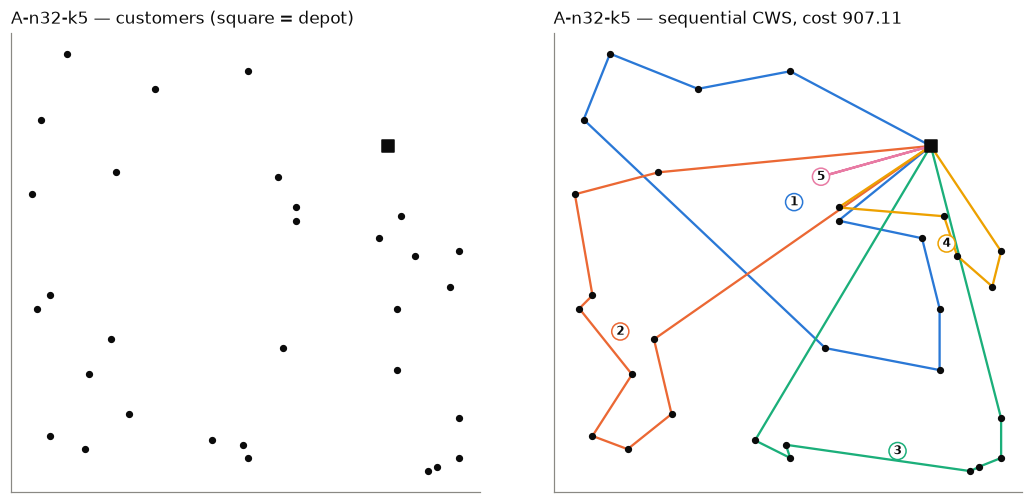

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
plot_routes(coords, [], axes[0], f"{name} — customers (square = depot)")
plot_routes(coords, seq, axes[1],
            f"{name} — sequential CWS, cost {vrp.solution_cost(seq, dist):.2f}")
fig.tight_layout()
fig.savefig(FIG_DIR / f"sequential_cws_{name}.png", bbox_inches="tight")
plt.show()

## 7. All 33 benchmark instances

The sequential CWS is now run on every instance. As reference we take, from Table 1 of
Juan et al. (2011):

* `paper_cws` — cost of their CWS solution (**parallel** version), the comparison asked
  for in the assignment;
* `bks` — best-known solution, computed with real (not rounded) distances.

Gaps are relative: $\text{gap} = 100\,(\text{cost} - \text{ref}) / \text{ref}$.

In [10]:
# Juan et al. (2011), Table 1: CWS cost (parallel version) and best-known solution.
PAPER = {  # name: (paper_cws, bks)
    "A-n32-k5": (843.69, 787.81), "A-n38-k5": (768.14, 734.18), "A-n45-k7": (1199.98, 1147.28),
    "A-n55-k9": (1099.84, 1074.46), "A-n60-k9": (1421.88, 1355.80), "A-n61-k9": (1102.23, 1039.08),
    "A-n65-k9": (1239.42, 1181.69), "A-n80-k10": (1860.94, 1766.50),
    "B-n50-k7": (748.80, 744.78), "B-n52-k7": (764.90, 750.08), "B-n57-k9": (1653.42, 1603.63),
    "B-n78-k10": (1264.56, 1229.27),
    "E-n22-k4": (388.77, 375.28), "E-n30-k3": (534.45, 535.80), "E-n33-k4": (843.10, 838.72),
    "E-n51-k5": (584.64, 524.94), "E-n76-k7": (737.74, 687.60), "E-n76-k10": (900.26, 837.36),
    "E-n76-k14": (1073.43, 1026.71),
    "F-n45-k4": (739.02, 724.57), "F-n72-k4": (256.19, 248.81), "F-n135-k7": (1219.32, 1170.65),
    "M-n101-k10": (833.51, 819.81), "M-n121-k7": (1068.14, 1045.16),
    "P-n22-k8": (590.62, 601.42), "P-n40-k5": (518.37, 461.73), "P-n50-k10": (734.32, 699.56),
    "P-n55-k15": (978.07, 991.48), "P-n65-k10": (851.67, 796.67), "P-n70-k10": (896.86, 830.02),
    "P-n76-k4": (689.13, 598.22), "P-n76-k5": (698.51, 635.04), "P-n101-k4": (765.38, 692.28),
}

In [11]:
rows = []
solutions = {}
for inst in vrp.CAPACITY:
    xy, q, cap = vrp.load_instance(inst)
    d = vrp.distance_matrix(xy)
    t0 = time.perf_counter()
    sol = vrp.sequential_cws(d, q, cap)
    elapsed = time.perf_counter() - t0
    assert vrp.is_feasible(sol, q, cap), inst
    solutions[inst] = (xy, sol)
    cost = vrp.solution_cost(sol, d)
    paper_cws, bks = PAPER[inst]
    rows.append({"instance": inst, "family": inst[0], "nodes": len(q), "capacity": cap,
                 "routes": len(sol), "cost": cost, "time_ms": 1000 * elapsed,
                 "paper_cws": paper_cws, "gap_paper_cws_%": 100 * (cost - paper_cws) / paper_cws,
                 "bks": bks, "gap_bks_%": 100 * (cost - bks) / bks})

results = pd.DataFrame(rows).set_index("instance")
results.round(2).to_csv(RESULTS_DIR / "sequential_cws.csv")
results.round(2)

,family,nodes,capacity,routes,cost,time_ms,paper_cws,gap_paper_cws_%,bks,gap_bks_%
instance,,,,,,,,,,
A-n32-k5,A,32,100,5,907.11,2.53,843.69,7.52,787.81,15.14
A-n38-k5,A,38,100,5,834.26,3.87,768.14,8.61,734.18,13.63
A-n45-k7,A,45,100,7,1251.38,6.69,1199.98,4.28,1147.28,9.07
A-n55-k9,A,55,100,9,1290.89,10.92,1099.84,17.37,1074.46,20.14
A-n60-k9,A,60,100,9,1572.97,13.74,1421.88,10.63,1355.80,16.02
A-n61-k9,A,61,100,9,1188.96,12.67,1102.23,7.87,1039.08,14.42
A-n65-k9,A,65,100,9,1479.40,14.41,1239.42,19.36,1181.69,25.19
A-n80-k10,A,80,100,10,1956.41,19.49,1860.94,5.13,1766.50,10.75
B-n50-k7,B,50,100,7,849.34,7.90,748.80,13.43,744.78,14.04


In [12]:
summary = results.groupby("family")[["gap_paper_cws_%", "gap_bks_%", "time_ms"]].mean()
summary.loc["all"] = results[["gap_paper_cws_%", "gap_bks_%", "time_ms"]].mean()
summary.round(2)

,gap_paper_cws_%,gap_bks_%,time_ms
family,,,
A,10.10,15.55,10.54
B,10.27,12.59,11.92
E,11.70,17.19,10.96
F,29.23,33.08,32.04
M,16.84,19.11,40.18
P,6.48,14.15,12.48
all,11.62,16.97,15.08


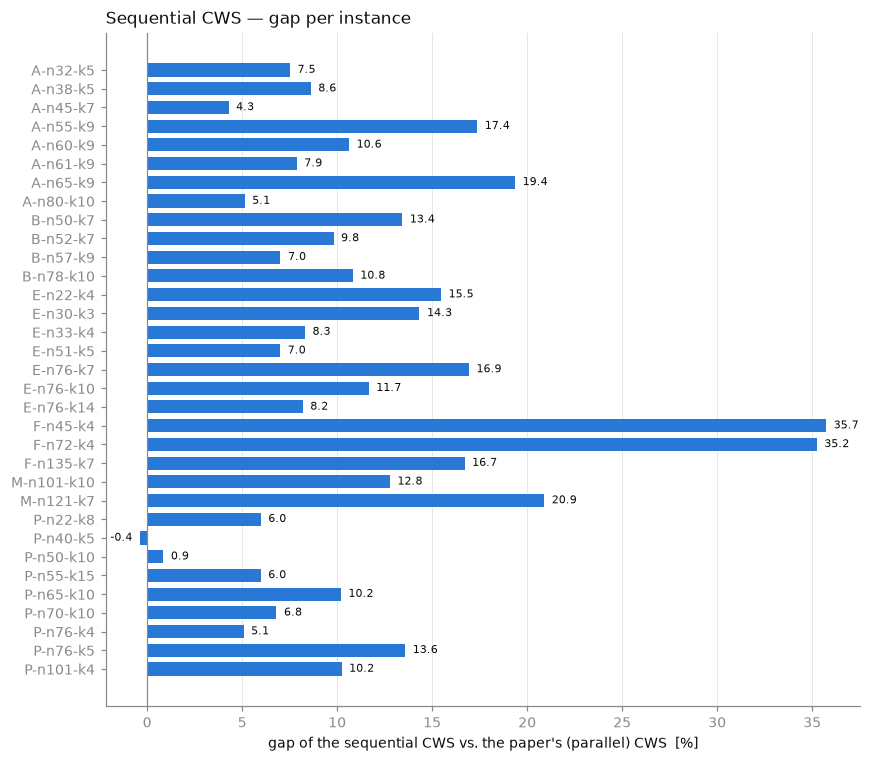

In [13]:
fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(results))[::-1]
ax.barh(y, results["gap_paper_cws_%"], height=0.7, color=ROUTE_COLORS[0])
ax.axvline(0, color=MUTED, lw=0.8)
ax.set_yticks(y, results.index)
ax.set_xlabel("gap of the sequential CWS vs. the paper's (parallel) CWS  [%]")
ax.set_title("Sequential CWS — gap per instance", loc="left", color=INK)
ax.grid(axis="x", color="#e5e4e0", lw=0.6)
ax.set_axisbelow(True)
for yi, g in zip(y, results["gap_paper_cws_%"]):
    ax.text(g + (0.4 if g >= 0 else -0.4), yi, f"{g:.1f}", va="center",
            ha="left" if g >= 0 else "right", fontsize=7, color=INK)
fig.tight_layout()
fig.savefig(FIG_DIR / "sequential_cws_gap.png", bbox_inches="tight")
plt.show()

Some solutions, one per family, to see what the routes look like. The sequential version
tends to produce good first routes and worse last ones: the first routes pick the best
savings freely, while the last routes are built from whatever customers are left, which are
often far apart from each other.

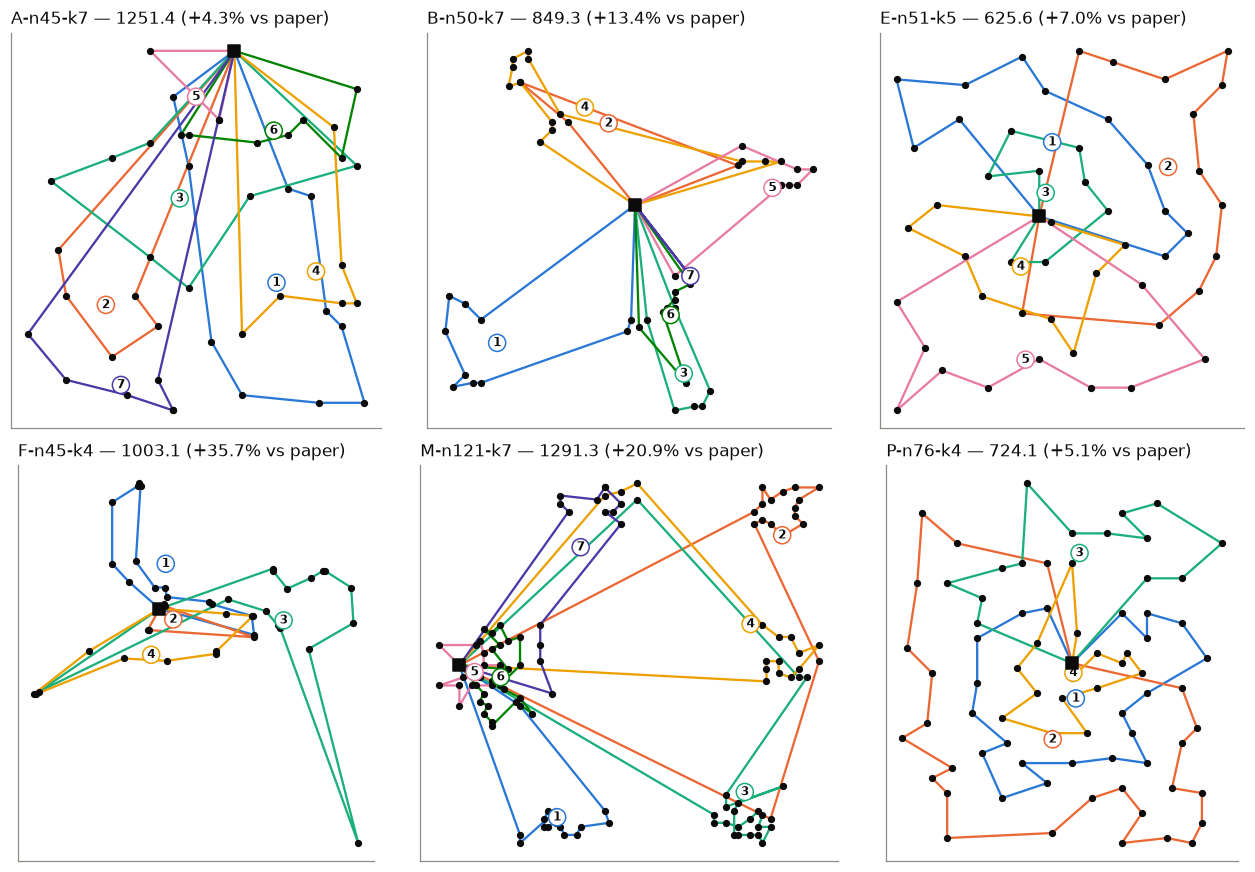

In [14]:
examples = ["A-n45-k7", "B-n50-k7", "E-n51-k5", "F-n45-k4", "M-n121-k7", "P-n76-k4"]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, inst in zip(axes.flat, examples):
    xy, sol = solutions[inst]
    r = results.loc[inst]
    plot_routes(xy, sol, ax, f"{inst} — {r.cost:.1f} ({r['gap_paper_cws_%']:+.1f}% vs paper)")
fig.tight_layout()
fig.savefig(FIG_DIR / "sequential_cws_examples.png", bbox_inches="tight")
plt.show()

## 8. Parallel CWS

`vrp.parallel_cws(dist, demand, capacity)` is the classic CWS used by Juan et al. (2011,
Figure 4, line 2) and the one behind the column `CWS Sol.` of their Table 1. It takes the
same arguments as the sequential version and reuses exactly the same building blocks; the
only difference is how the savings list is walked:

1. Build the savings list and the dummy solution.
2. Take the edges **once each, in order of decreasing saving**. If `check_merging_conditions`
   holds, merge the two routes with `merge_routes_using_edge` — **any two routes**, not
   only the one being built.
3. Discard the edge, whether it was used or not, and continue with the next one.

Discarding a rejected edge is safe for the same reason as in the sequential version: routes
only grow, so its conditions can only get worse. Many routes therefore grow at the same
time, and every merge is chosen among all the remaining savings of the whole solution,
instead of among the savings that touch a single route.

In [15]:
par = vrp.parallel_cws(dist, demand, capacity)
print(f"feasible: {vrp.is_feasible(par, demand, capacity)} | {len(par)} routes | "
      f"cost = {vrp.solution_cost(par, dist):.2f}  (JORS CWS: {843.69})")
pd.DataFrame({"customers": [len(r) for r in par],
              "load": [demand[r].sum() for r in par],
              "cost": [vrp.route_cost(r, dist) for r in par],
              "route": [" ".join(map(str, r)) for r in par]},
             index=pd.RangeIndex(1, len(par) + 1, name="route #")).round(2)

feasible: True | 5 routes | cost = 843.69  (JORS CWS: 843.69)


,customers,load,cost,route
route #,,,,
1,5,90.0,111.92,12 1 13 7 16
2,7,99.0,213.22,23 2 3 17 19 31 21
3,10,92.0,257.90,14 22 9 8 11 4 28 18 6 26
4,2,38.0,65.60,24 30
5,7,91.0,195.05,27 29 15 10 25 5 20


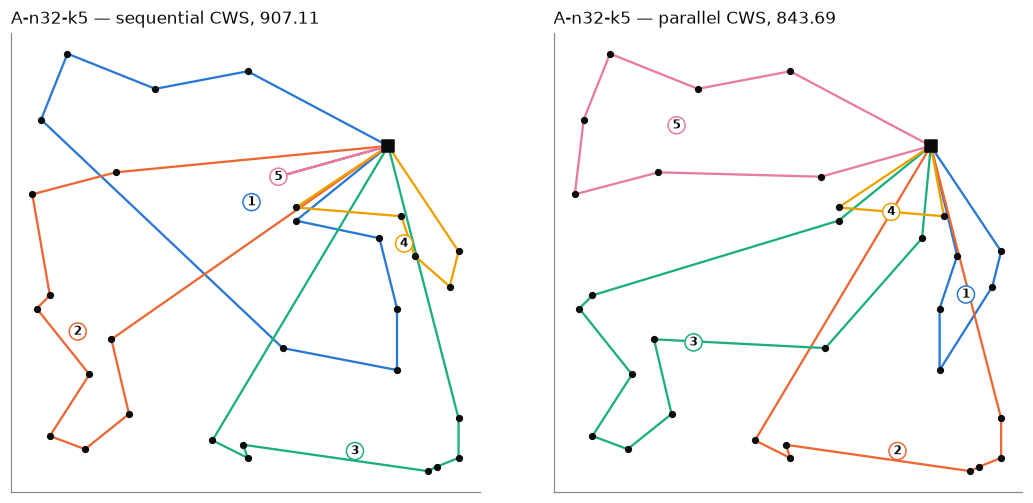

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
plot_routes(coords, seq, axes[0], f"{name} — sequential CWS, {vrp.solution_cost(seq, dist):.2f}")
plot_routes(coords, par, axes[1], f"{name} — parallel CWS, {vrp.solution_cost(par, dist):.2f}")
fig.tight_layout()
fig.savefig(FIG_DIR / f"sequential_vs_parallel_{name}.png", bbox_inches="tight")
plt.show()

The same number of routes, but the parallel version no longer leaves a customer alone at the
end: its routes are more compact and the total distance drops by about 7 %.

### Parallel vs. sequential vs. JORS on the 33 instances

In [17]:
par_rows = []
par_solutions = {}
for inst in vrp.CAPACITY:
    xy, q, cap = vrp.load_instance(inst)
    d = vrp.distance_matrix(xy)
    t0 = time.perf_counter()
    sol = vrp.parallel_cws(d, q, cap)
    elapsed = time.perf_counter() - t0
    assert vrp.is_feasible(sol, q, cap), inst
    par_solutions[inst] = (xy, sol)
    par_rows.append({"instance": inst, "par_routes": len(sol),
                     "par_cost": vrp.solution_cost(sol, d), "par_time_ms": 1000 * elapsed})

comparison = results[["family", "nodes", "capacity", "routes", "cost", "paper_cws", "bks"]].rename(
    columns={"routes": "seq_routes", "cost": "seq_cost"}).join(pd.DataFrame(par_rows).set_index("instance"))
comparison["gap_seq_paper_cws_%"] = 100 * (comparison.seq_cost - comparison.paper_cws) / comparison.paper_cws
comparison["gap_par_paper_cws_%"] = 100 * (comparison.par_cost - comparison.paper_cws) / comparison.paper_cws
comparison["gap_par_bks_%"] = 100 * (comparison.par_cost - comparison.bks) / comparison.bks
comparison["improvement_par_vs_seq_%"] = 100 * (comparison.seq_cost - comparison.par_cost) / comparison.seq_cost

comparison.round(2).to_csv(RESULTS_DIR / "cws_comparison.csv")
comparison[["seq_cost", "par_cost", "paper_cws", "par_routes", "gap_seq_paper_cws_%",
            "gap_par_paper_cws_%", "gap_par_bks_%"]].round(2)

,seq_cost,par_cost,paper_cws,par_routes,gap_seq_paper_cws_%,gap_par_paper_cws_%,gap_par_bks_%
instance,,,,,,,
A-n32-k5,907.11,843.69,843.69,5,7.52,-0.00,7.09
A-n38-k5,834.26,768.13,768.14,6,8.61,-0.00,4.62
A-n45-k7,1251.38,1199.98,1199.98,7,4.28,-0.00,4.59
A-n55-k9,1290.89,1099.84,1099.84,9,17.37,-0.00,2.36
A-n60-k9,1572.97,1421.88,1421.88,9,10.63,0.00,4.87
A-n61-k9,1188.96,1102.23,1102.23,10,7.87,-0.00,6.08
A-n65-k9,1479.40,1239.42,1239.42,10,19.36,0.00,4.89
A-n80-k10,1956.41,1860.94,1860.94,10,5.13,0.00,5.35
B-n50-k7,849.34,748.80,748.80,7,13.43,0.00,0.54


In [18]:
cols = ["gap_seq_paper_cws_%", "gap_par_paper_cws_%", "gap_par_bks_%", "improvement_par_vs_seq_%"]
summary_par = comparison.groupby("family")[cols].mean()
summary_par.loc["all"] = comparison[cols].mean()
exact = (comparison.par_cost - comparison.paper_cws).abs() < 0.015  # JORS rounds to 2 decimals
print(f"parallel CWS equal to the JORS CWS in {exact.sum()} of {len(exact)} instances")
summary_par.round(2)

parallel CWS equal to the JORS CWS in 27 of 33 instances


,gap_seq_paper_cws_%,gap_par_paper_cws_%,gap_par_bks_%,improvement_par_vs_seq_%
family,,,,
A,10.10,-0.00,4.98,8.98
B,10.27,-0.00,2.12,9.27
E,11.70,-0.13,4.81,10.50
F,29.23,-0.00,3.04,22.23
M,16.84,-0.00,1.93,14.31
P,6.48,0.24,7.46,5.71
all,11.62,0.04,4.91,9.97


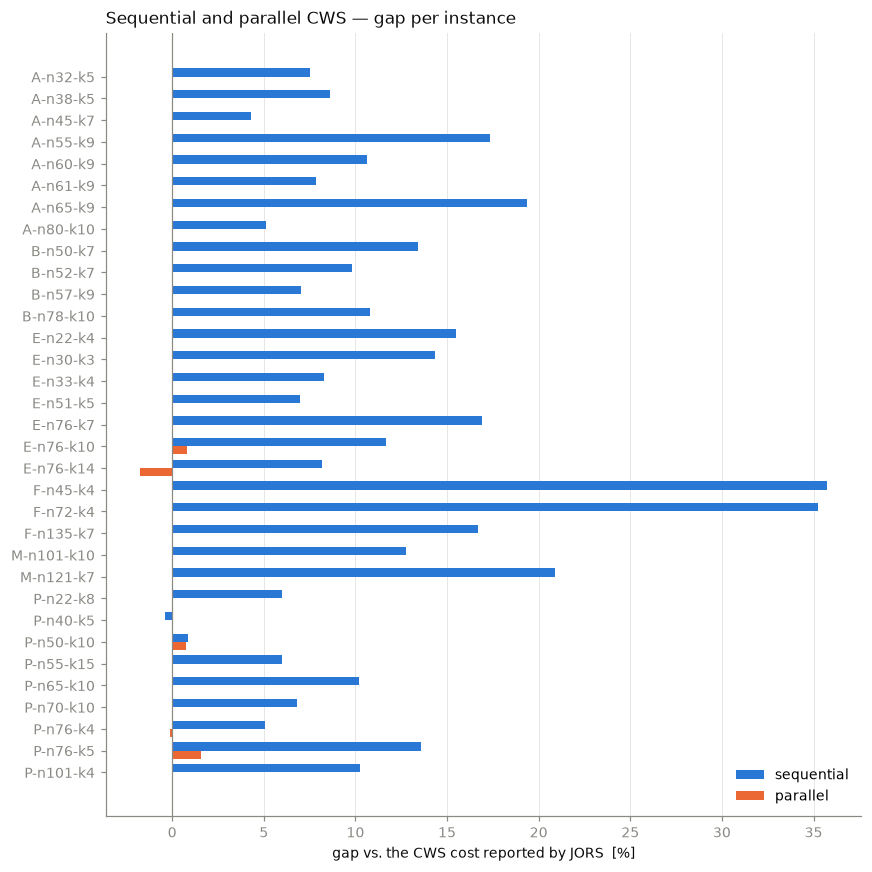

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
y = np.arange(len(comparison))[::-1]
h = 0.38
ax.barh(y + h / 2, comparison["gap_seq_paper_cws_%"], height=h, color=ROUTE_COLORS[0], label="sequential")
ax.barh(y - h / 2, comparison["gap_par_paper_cws_%"], height=h, color=ROUTE_COLORS[1], label="parallel")
ax.axvline(0, color=MUTED, lw=0.8)
ax.set_yticks(y, comparison.index)
ax.set_xlabel("gap vs. the CWS cost reported by JORS  [%]")
ax.set_title("Sequential and parallel CWS — gap per instance", loc="left", color=INK)
ax.grid(axis="x", color="#e5e4e0", lw=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(FIG_DIR / "cws_gap_comparison.png", bbox_inches="tight")
plt.show()

### Instances that do not match JORS exactly

The CWS does not say how to order edges with **the same saving**, and these instances have
integer coordinates, so ties are common. Our list keeps the generation order $(i, j)$ for
tied edges, as the course code does. If the ties are broken the other way round — the pair
generated **last** goes first — and the parallel CWS is run again with the same building
blocks, the costs of JORS are reproduced in all 33 instances. The differences come only
from the tie-breaking rule of the savings list, not from the merging logic.

In [20]:
def parallel_cws_reversed_ties(dist, demand, capacity):
    '''Parallel CWS with tied savings taken in reverse generation order (experiment only).'''
    i, j = np.triu_indices(len(dist), k=1)
    i, j = i[i > 0], j[i > 0]
    s = dist[0, i] + dist[0, j] - dist[i, j]
    order = np.lexsort((-np.arange(len(s)), -s))  # by decreasing saving, then last pair first
    routes, route_of, load = vrp.construct_initial_sol(demand)
    for a, b in zip(i[order], j[order]):
        if vrp.check_merging_conditions(a, b, routes, route_of, load, capacity):
            vrp.merge_routes_using_edge(a, b, routes, route_of, load)
    return list(routes.values())

rev_cost = {}
for inst in vrp.CAPACITY:
    xy, q, cap = vrp.load_instance(inst)
    d = vrp.distance_matrix(xy)
    rev_cost[inst] = vrp.solution_cost(parallel_cws_reversed_ties(d, q, cap), d)
comparison["par_cost_reversed_ties"] = pd.Series(rev_cost)

exact_rev = (comparison.par_cost_reversed_ties - comparison.paper_cws).abs() < 0.015
print(f"with reversed ties: equal to the JORS CWS in {exact_rev.sum()} of {len(exact_rev)} instances")
comparison.loc[~exact, ["par_cost", "par_cost_reversed_ties", "paper_cws"]].round(2)

with reversed ties: equal to the JORS CWS in 33 of 33 instances


,par_cost,par_cost_reversed_ties,paper_cws
instance,,,
E-n76-k7,738.13,737.74,737.74
E-n76-k10,907.39,900.26,900.26
E-n76-k14,1054.60,1073.43,1073.43
P-n50-k10,739.84,734.32,734.32
P-n76-k4,688.34,689.13,689.13
P-n76-k5,709.38,698.51,698.51


## 9. Remarks

* Both versions are extremely fast (milliseconds per instance) and always return a feasible
  solution.
* The **parallel** version reproduces the CWS costs reported by Juan et al. (2011) in 27 of
  the 33 instances, and in all 33 when tied savings are taken in reverse generation order:
  the remaining differences (between −1.8 % and +1.6 %) come only from the tie-breaking rule
  of the savings list.
* The **sequential** version is clearly worse: the first routes take the best savings freely,
  but the last ones are built from the customers that are left over, often scattered or even
  alone. The Fisher instances (`F`), with clustered customers, suffer most. This agrees with
  the literature and is the reason why the paper uses the parallel version.
* The CWS does not limit the number of vehicles to the $k$ of the instance name; when a
  route cannot be merged any further it simply stays, so a solution may use more routes
  than the best-known one.